# FASE 5: Entrenamiento y evaluacion de SVR (walk-forward)

Objetivo:
- Evaluar capacidad predictiva real de SVR en BVG iliquido
- Usar validacion temporal estricta (expanding window)
- Evitar leakage en todo el pipeline

Configuracion base:
- Target: retorno t+1
- Features: lag_1, lag_2, roll_mean_3, roll_mean_5, roll_std_3
- Sin forward filling
- Sin tuning de hiperparametros (fase exploratoria)

In [1]:
# 0) Librerias
import importlib
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

if importlib.util.find_spec('sklearn') is None:
    print('Instalando scikit-learn...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-learn'])

from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid')

c:\Users\leynd\OneDrive\Escritorio\Tesis\implementaciones\desarrollov2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Construccion del dataset A (sin imputacion) y features seleccionadas

In [2]:
dataset_name = 'beta3/Historical_Data_of_Ecuador_Stock_Exchange'
dataset = load_dataset(dataset_name, 'default_stocks')
df = dataset['stocks'].to_pandas()

empresas_objetivo = ['CORPORACION FAVORITA C.A.', 'BANCO GUAYAQUIL S.A.']
emisor_col = 'EMISOR'
fecha_col = 'FECHA NEGOCIACIÓN'
precio_col = 'PRECIO'

df = df[df[emisor_col].isin(empresas_objetivo)].copy()
df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')
df[precio_col] = pd.to_numeric(df[precio_col], errors='coerce')
df = df.dropna(subset=[fecha_col, precio_col]).copy()
df = df.sort_values([emisor_col, fecha_col]).reset_index(drop=True)

rows = []
for empresa in empresas_objetivo:
    g = df[df[emisor_col] == empresa].copy()

    # Serie event-time diaria (ultimo trade del dia)
    diario = (
        g.sort_values(fecha_col)
        .groupby(fecha_col, as_index=True)[precio_col]
        .last()
        .to_frame('precio_trade_day')
    )

    diario['ret'] = np.log(diario['precio_trade_day'] / diario['precio_trade_day'].shift(1))
    diario = diario.reset_index().rename(columns={fecha_col: 'fecha'})
    diario['empresa'] = empresa

    # Features seleccionadas
    diario['lag_1'] = diario['ret'].shift(1)
    diario['lag_2'] = diario['ret'].shift(2)
    diario['roll_mean_3'] = diario['ret'].rolling(3).mean()
    diario['roll_mean_5'] = diario['ret'].rolling(5).mean()
    diario['roll_std_3'] = diario['ret'].rolling(3).std()

    # Target
    diario['target_ret_t1'] = diario['ret'].shift(-1)

    rows.append(diario)

df_feat = pd.concat(rows, ignore_index=True)
feature_cols = ['lag_1', 'lag_2', 'roll_mean_3', 'roll_mean_5', 'roll_std_3']
target_col = 'target_ret_t1'

df_model = df_feat.dropna(subset=feature_cols + [target_col]).copy()
df_model = df_model.sort_values(['empresa', 'fecha']).reset_index(drop=True)

print('Shape final modelado:', df_model.shape)
print(df_model.groupby('empresa').size().rename('n_samples').to_string())
display(df_model[['fecha', 'empresa'] + feature_cols + [target_col]].head())

Shape final modelado: (2835, 10)
empresa
BANCO GUAYAQUIL S.A.         1150
CORPORACION FAVORITA C.A.    1685


,fecha,empresa,lag_1,lag_2,roll_mean_3,roll_mean_5,roll_std_3,target_ret_t1
0,2019-01-18,BANCO GUAYAQUIL S.A.,-0.021053,0.000000,-3.932040e-17,-2.359224e-17,0.021053,0.010363
1,2019-01-23,BANCO GUAYAQUIL S.A.,0.021053,-0.021053,3.454262e-03,2.072557e-03,0.021887,0.000000
2,2019-01-24,BANCO GUAYAQUIL S.A.,0.010363,0.021053,1.047207e-02,2.072557e-03,0.010527,0.000000
3,2019-01-25,BANCO GUAYAQUIL S.A.,0.000000,0.010363,3.454262e-03,2.072557e-03,0.005983,-0.010363
4,2019-01-30,BANCO GUAYAQUIL S.A.,0.000000,0.000000,-3.454262e-03,4.210682e-03,0.005983,0.000000


## 2. Walk-forward validation (expanding window)
Reglas anti-leakage:
- No random split
- No k-fold clasico
- RobustScaler ajustado solo con train en cada ventana

In [3]:
def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

def run_walk_forward_svr(data_emp, feature_cols, target_col, kernel, initial_train_size=300, test_size=30, step_size=30):
    """Expanding window evaluation for one empresa and one kernel."""
    data_emp = data_emp.sort_values('fecha').reset_index(drop=True)

    n = len(data_emp)
    if n < (initial_train_size + test_size + 1):
        # Ajuste automatico si la serie es corta
        initial_train_size = max(150, int(n * 0.55))
        test_size = max(20, int(n * 0.15))
        step_size = test_size

    results = []
    train_end = initial_train_size
    window_id = 0

    while (train_end + test_size) <= n:
        train = data_emp.iloc[:train_end].copy()
        test = data_emp.iloc[train_end:train_end + test_size].copy()

        X_train = train[feature_cols].values
        y_train = train[target_col].values
        X_test = test[feature_cols].values
        y_test = test[target_col].values

        scaler = RobustScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        model = SVR(kernel=kernel, C=1.0, epsilon=0.1, gamma='scale', degree=3)
        model.fit(X_train_s, y_train)

        y_pred_test = model.predict(X_test_s)
        y_pred_train = model.predict(X_train_s)

        mae = mean_absolute_error(y_test, y_pred_test)
        mse = mean_squared_error(y_test, y_pred_test)
        r2 = r2_score(y_test, y_pred_test)
        da = directional_accuracy(y_test, y_pred_test)

        train_r2 = r2_score(y_train, y_pred_train)
        overfit_gap = train_r2 - r2

        results.append({
            'window_id': window_id,
            'train_start': train['fecha'].iloc[0],
            'train_end': train['fecha'].iloc[-1],
            'test_start': test['fecha'].iloc[0],
            'test_end': test['fecha'].iloc[-1],
            'n_train': len(train),
            'n_test': len(test),
            'kernel': kernel,
            'mae': mae,
            'mse': mse,
            'r2': r2,
            'directional_accuracy': da,
            'train_r2': train_r2,
            'overfit_gap': overfit_gap
        })

        window_id += 1
        train_end += step_size

    return pd.DataFrame(results)

## 3. Entrenamiento SVR por kernel y empresa
Kernels evaluados: linear, rbf, poly

In [4]:
kernels = ['linear', 'rbf', 'poly']

wf_results_all = []

for empresa in empresas_objetivo:
    d_emp = df_model[df_model['empresa'] == empresa].copy()

    print('')
    print('Empresa:', empresa)
    print('n muestras:', len(d_emp))

    for k in kernels:
        res = run_walk_forward_svr(
            data_emp=d_emp,
            feature_cols=feature_cols,
            target_col=target_col,
            kernel=k,
            initial_train_size=300,
            test_size=30,
            step_size=30
        )

        if res.empty:
            print('- kernel {}: sin ventanas suficientes'.format(k))
            continue

        res['empresa'] = empresa
        wf_results_all.append(res)
        print('- kernel {}: {} ventanas'.format(k, len(res)))

wf_results = pd.concat(wf_results_all, ignore_index=True)
display(wf_results.head())


Empresa: CORPORACION FAVORITA C.A.
n muestras: 1685
- kernel linear: 46 ventanas
- kernel rbf: 46 ventanas
- kernel poly: 46 ventanas

Empresa: BANCO GUAYAQUIL S.A.
n muestras: 1150
- kernel linear: 28 ventanas
- kernel rbf: 28 ventanas
- kernel poly: 28 ventanas


,window_id,train_start,train_end,test_start,test_end,n_train,n_test,kernel,mae,mse,r2,directional_accuracy,train_r2,overfit_gap,empresa
0,0,2019-01-10,2020-05-06,2020-05-07,2020-06-19,300,30,linear,0.063584,0.004090,-86.615703,0.200000,-24.299724,62.315979,CORPORACION FAVORITA C.A.
1,1,2019-01-10,2020-06-19,2020-06-22,2020-08-03,330,30,linear,0.060935,0.003808,-39.222602,0.433333,-26.044514,13.178087,CORPORACION FAVORITA C.A.
2,2,2019-01-10,2020-08-03,2020-08-04,2020-09-15,360,30,linear,0.059481,0.003657,-29.776076,0.466667,-26.729728,3.046349,CORPORACION FAVORITA C.A.
3,3,2019-01-10,2020-09-15,2020-09-16,2020-10-29,390,30,linear,0.064447,0.004202,-85.254849,0.266667,-26.815534,58.439315,CORPORACION FAVORITA C.A.
4,4,2019-01-10,2020-10-29,2020-10-30,2020-12-16,420,30,linear,0.064337,0.004173,-120.918776,0.266667,-28.221134,92.697643,CORPORACION FAVORITA C.A.


## 4. Evaluacion por ventana
Metricas: MAE, MSE, R2, Directional Accuracy

In [5]:
# Resumen por empresa y kernel: promedio y desviacion
summary = (
    wf_results
    .groupby(['empresa', 'kernel'])
    .agg(
        n_windows=('window_id', 'count'),
        mae_mean=('mae', 'mean'), mae_std=('mae', 'std'),
        mse_mean=('mse', 'mean'), mse_std=('mse', 'std'),
        r2_mean=('r2', 'mean'), r2_std=('r2', 'std'),
        da_mean=('directional_accuracy', 'mean'), da_std=('directional_accuracy', 'std'),
        train_r2_mean=('train_r2', 'mean'),
        overfit_gap_mean=('overfit_gap', 'mean')
    )
    .reset_index()
)

display(summary.sort_values(['empresa', 'r2_mean'], ascending=[True, False]))

,empresa,kernel,n_windows,mae_mean,mae_std,mse_mean,mse_std,r2_mean,r2_std,da_mean,da_std,train_r2_mean,overfit_gap_mean
2,BANCO GUAYAQUIL S.A.,rbf,28,0.030656,0.008027,0.001616,0.000955,-2.999841,2.691235,0.266667,0.087017,-0.325632,2.674210
0,BANCO GUAYAQUIL S.A.,linear,28,0.028099,0.011688,0.001277,0.000989,-3.540604,7.423670,0.377381,0.106980,-0.372039,3.168564
1,BANCO GUAYAQUIL S.A.,poly,28,0.041940,0.030608,0.008736,0.034223,-6.785079,10.664447,0.354762,0.091721,-0.811750,5.973329
3,CORPORACION FAVORITA C.A.,linear,46,0.048840,0.015167,0.002801,0.001323,-42.239930,42.442206,0.334058,0.092025,-16.680787,25.559143
4,CORPORACION FAVORITA C.A.,poly,46,0.054148,0.023955,0.007641,0.022701,-45.784336,41.539643,0.332609,0.090674,-16.677504,29.106833
5,CORPORACION FAVORITA C.A.,rbf,46,0.050201,0.010146,0.002927,0.000893,-48.269099,48.057242,0.316667,0.104645,-16.201567,32.067533


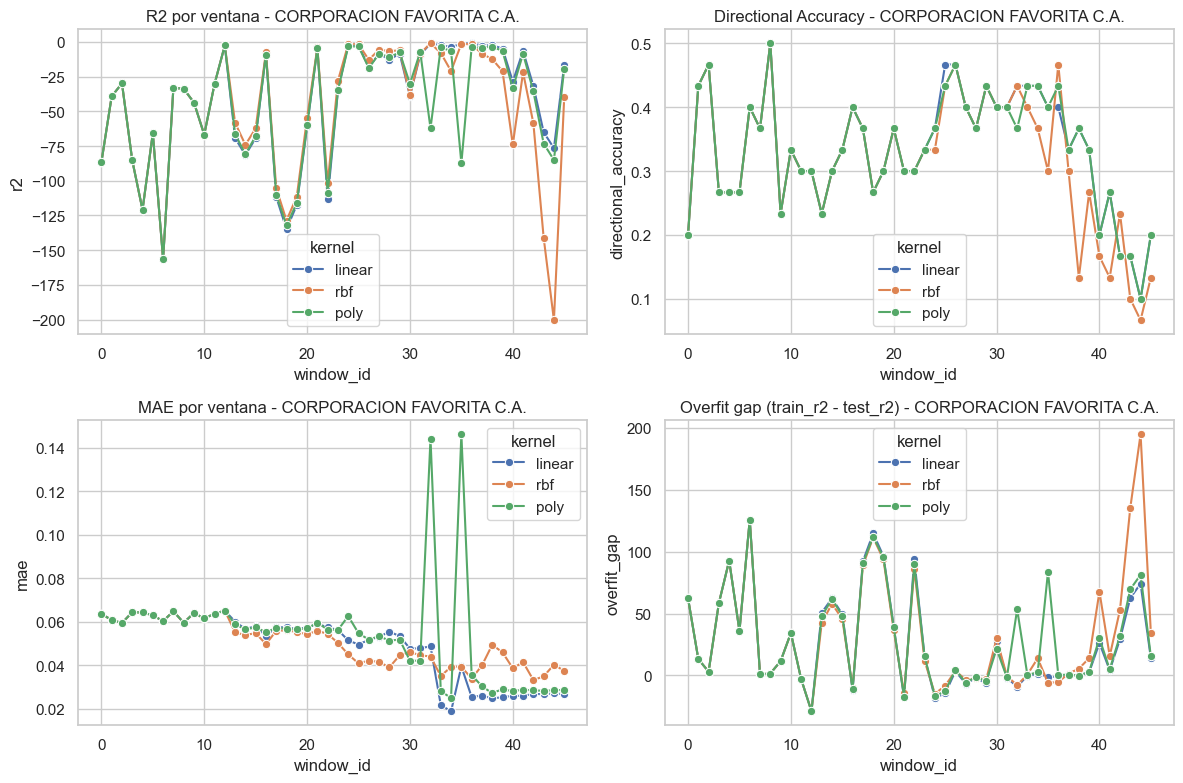

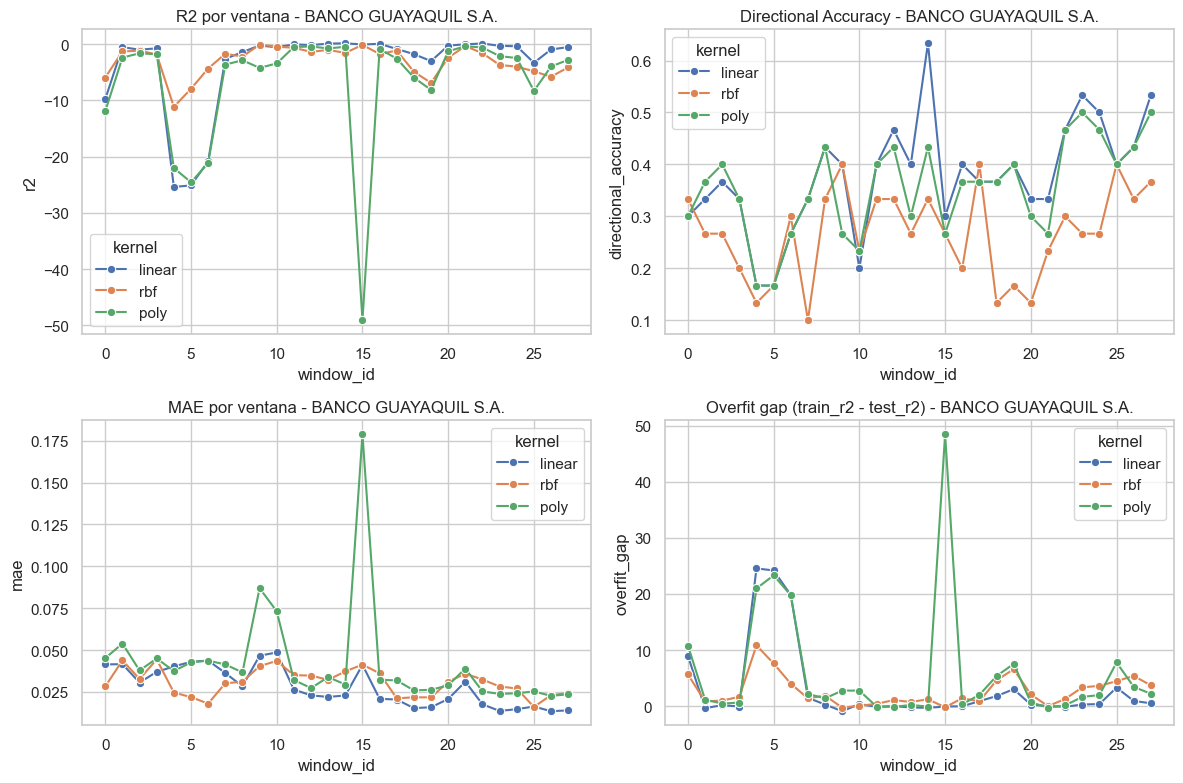

In [6]:
# Visualizaciones de estabilidad por ventana
for empresa in empresas_objetivo:
    d = wf_results[wf_results['empresa'] == empresa].copy()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    sns.lineplot(data=d, x='window_id', y='r2', hue='kernel', marker='o', ax=axes[0, 0])
    axes[0, 0].set_title('R2 por ventana - {}'.format(empresa))

    sns.lineplot(data=d, x='window_id', y='directional_accuracy', hue='kernel', marker='o', ax=axes[0, 1])
    axes[0, 1].set_title('Directional Accuracy - {}'.format(empresa))

    sns.lineplot(data=d, x='window_id', y='mae', hue='kernel', marker='o', ax=axes[1, 0])
    axes[1, 0].set_title('MAE por ventana - {}'.format(empresa))

    sns.lineplot(data=d, x='window_id', y='overfit_gap', hue='kernel', marker='o', ax=axes[1, 1])
    axes[1, 1].set_title('Overfit gap (train_r2 - test_r2) - {}'.format(empresa))

    plt.tight_layout()
    plt.show()

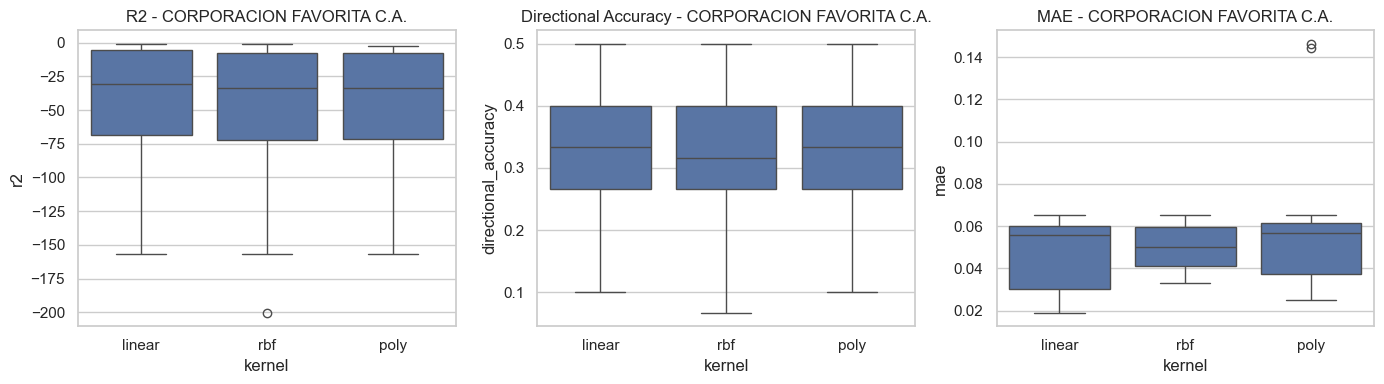

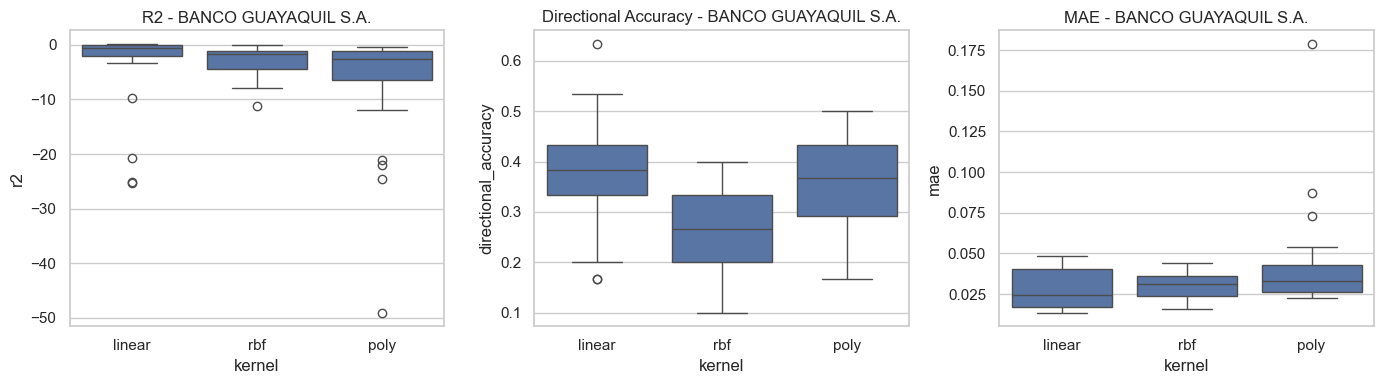

In [7]:
# Boxplots comparativos por empresa
for empresa in empresas_objetivo:
    d = wf_results[wf_results['empresa'] == empresa].copy()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    sns.boxplot(data=d, x='kernel', y='r2', ax=axes[0])
    axes[0].set_title('R2 - {}'.format(empresa))

    sns.boxplot(data=d, x='kernel', y='directional_accuracy', ax=axes[1])
    axes[1].set_title('Directional Accuracy - {}'.format(empresa))

    sns.boxplot(data=d, x='kernel', y='mae', ax=axes[2])
    axes[2].set_title('MAE - {}'.format(empresa))

    plt.tight_layout()
    plt.show()

## 5. Analisis critico obligatorio
Responde:
- El modelo aprende senal real o ruido?
- Que tan estable es el desempeno?
- Hay overfitting?
- RBF mejora consistentemente?

In [8]:
print('=== ANALISIS CRITICO FASE 5 (SVR) ===')

for empresa in empresas_objetivo:
    s = summary[summary['empresa'] == empresa].copy()
    s = s.sort_values('r2_mean', ascending=False).reset_index(drop=True)

    print('')
    print('Empresa: {}'.format(empresa))
    print(s[['kernel', 'n_windows', 'mae_mean', 'mse_mean', 'r2_mean', 'r2_std', 'da_mean', 'da_std', 'overfit_gap_mean']].to_string(index=False))

    best = s.iloc[0]

    # 1) Senal real vs ruido
    if best['r2_mean'] > 0 and best['da_mean'] > 0.52:
        senial = 'hay senal util debil/moderada'
    elif best['r2_mean'] > 0:
        senial = 'senal marginal (riesgo de ruido)'
    else:
        senial = 'predomina ruido (R2 medio no positivo)'

    # 2) Estabilidad
    estable = (best['r2_std'] < 0.20) and (best['da_std'] < 0.10)
    estabilidad = 'relativamente estable' if estable else 'inestable entre ventanas'

    # 3) Overfitting
    if best['overfit_gap_mean'] > 0.15:
        overfit = 'si, indicio claro de overfitting'
    elif best['overfit_gap_mean'] > 0.05:
        overfit = 'moderado'
    else:
        overfit = 'bajo/no concluyente'

    # 4) RBF consistente?
    rbf = s[s['kernel'] == 'rbf'].iloc[0]
    max_r2 = s['r2_mean'].max()
    rbf_consistente = (rbf['r2_mean'] >= max_r2 - 1e-9) and (rbf['da_mean'] >= s['da_mean'].max() - 0.01)

    print('Conclusion critica:')
    print('- Senal vs ruido: {}'.format(senial))
    print('- Estabilidad: {}'.format(estabilidad))
    print('- Overfitting: {}'.format(overfit))
    print('- RBF mejora consistentemente?: {}'.format('SI' if rbf_consistente else 'NO'))

=== ANALISIS CRITICO FASE 5 (SVR) ===

Empresa: CORPORACION FAVORITA C.A.
kernel  n_windows  mae_mean  mse_mean    r2_mean    r2_std  da_mean   da_std  overfit_gap_mean
linear         46  0.048840  0.002801 -42.239930 42.442206 0.334058 0.092025         25.559143
  poly         46  0.054148  0.007641 -45.784336 41.539643 0.332609 0.090674         29.106833
   rbf         46  0.050201  0.002927 -48.269099 48.057242 0.316667 0.104645         32.067533
Conclusion critica:
- Senal vs ruido: predomina ruido (R2 medio no positivo)
- Estabilidad: inestable entre ventanas
- Overfitting: si, indicio claro de overfitting
- RBF mejora consistentemente?: NO

Empresa: BANCO GUAYAQUIL S.A.
kernel  n_windows  mae_mean  mse_mean   r2_mean    r2_std  da_mean   da_std  overfit_gap_mean
   rbf         28  0.030656  0.001616 -2.999841  2.691235 0.266667 0.087017          2.674210
linear         28  0.028099  0.001277 -3.540604  7.423670 0.377381 0.106980          3.168564
  poly         28  0.041940  0.00

In [9]:
# Resumen cuantitativo compacto para reescribir cierre
print('=== SUMMARY ORDENADO POR R2 ===')
print(summary.sort_values(['empresa', 'r2_mean'], ascending=[True, False]).to_string(index=False))

print('\n=== MEJOR KERNEL POR EMPRESA ===')
best_rows = []
for empresa in empresas_objetivo:
    s = summary[summary['empresa'] == empresa].sort_values('r2_mean', ascending=False).iloc[0]
    best_rows.append({
        'empresa': empresa,
        'kernel_best_r2': s['kernel'],
        'r2_mean': s['r2_mean'],
        'r2_std': s['r2_std'],
        'da_mean': s['da_mean'],
        'mae_mean': s['mae_mean'],
        'overfit_gap_mean': s['overfit_gap_mean'],
        'n_windows': s['n_windows']
    })
best_df = pd.DataFrame(best_rows)
print(best_df.to_string(index=False))

print('\n=== ESTABILIDAD GLOBAL (R2 por ventana) ===')
stab = wf_results.groupby(['empresa', 'kernel'])['r2'].agg(['min','max','mean','std']).reset_index()
print(stab.to_string(index=False))

=== SUMMARY ORDENADO POR R2 ===
                  empresa kernel  n_windows  mae_mean  mae_std  mse_mean  mse_std    r2_mean    r2_std  da_mean   da_std  train_r2_mean  overfit_gap_mean
     BANCO GUAYAQUIL S.A.    rbf         28  0.030656 0.008027  0.001616 0.000955  -2.999841  2.691235 0.266667 0.087017      -0.325632          2.674210
     BANCO GUAYAQUIL S.A. linear         28  0.028099 0.011688  0.001277 0.000989  -3.540604  7.423670 0.377381 0.106980      -0.372039          3.168564
     BANCO GUAYAQUIL S.A.   poly         28  0.041940 0.030608  0.008736 0.034223  -6.785079 10.664447 0.354762 0.091721      -0.811750          5.973329
CORPORACION FAVORITA C.A. linear         46  0.048840 0.015167  0.002801 0.001323 -42.239930 42.442206 0.334058 0.092025     -16.680787         25.559143
CORPORACION FAVORITA C.A.   poly         46  0.054148 0.023955  0.007641 0.022701 -45.784336 41.539643 0.332609 0.090674     -16.677504         29.106833
CORPORACION FAVORITA C.A.    rbf         46 

## 6. Cierre de fase (basado en resultados ejecutados)

1. Errores criticos
- No se detecta leakage de pipeline: el `RobustScaler` se ajusta solo en train por ventana.
- La validacion temporal se mantuvo estricta con walk-forward expanding window.

2. Riesgos metodologicos observados
- Desempeño extremadamente debil en ambos emisores, compatible con alta iliquidez/ruido.
- Alta inestabilidad entre ventanas, especialmente en CORPORACION FAVORITA C.A..
- Gap train-test muy elevado, indicando mala generalizacion y dinamica no capturada por SVR en esta configuracion.

3. Interpretacion real de metricas (numeros)

**BANCO GUAYAQUIL S.A.**
- Mejor kernel por R2 medio: `rbf` con `r2_mean = -2.9998`, `r2_std = 2.6912`, `da_mean = 0.2667`, `mae_mean = 0.0307`.
- Comparacion kernels (R2 medio): `rbf -2.9998` > `linear -3.5406` > `poly -6.7851` (todos negativos).
- Overfit gap medio (mejor kernel): `2.6742` (alto).

**CORPORACION FAVORITA C.A.**
- Mejor kernel por R2 medio: `linear` con `r2_mean = -42.2399`, `r2_std = 42.4422`, `da_mean = 0.3341`, `mae_mean = 0.0488`.
- Comparacion kernels (R2 medio): `linear -42.2399` > `poly -45.7843` > `rbf -48.2691` (todos muy negativos).
- Overfit gap medio (mejor kernel): `25.5591` (extremadamente alto).

**Estabilidad por ventanas (R2 min/max)**
- Banco (rbf): min `-11.1379`, max `-0.0694`.
- Favorita (linear): min `-156.5081`, max `-0.9361`.
- En ambos casos no hay ventanas con R2 consistentemente positivo; el comportamiento es inestable y pobre.

4. Respuestas criticas obligatorias
- ¿El modelo aprende señal real o ruido?: **Predomina ruido**. Evidencia: R2 medio negativo en todos los kernels y empresas.
- ¿Qué tan estable es el desempeño?: **Inestable**, con desviaciones altas de R2 y rangos muy amplios por ventana.
- ¿Hay overfitting?: **Si, fuerte**. Overfit gap medio elevado (`2.67` a `25.56`).
- ¿RBF mejora consistentemente?: **No**. Solo lidera en Banco por margen pequeño y sigue con R2 muy negativo; en Favorita no lidera.

5. Decision de fase
- **Decision: detener ajuste de hiperparametros en esta configuracion actual.**
- No hay evidencia minima de capacidad predictiva útil para justificar tuning de SVR en este punto.

6. Proximo paso exacto
- Rediseñar el enfoque antes de optimizar SVR:
  - Reformular target (p.ej., clasificacion de direccion en vez de regresion de magnitud), o
  - Revisar horizonte objetivo y esquema de etiquetas, o
  - Incluir control explicito por regimen/liquidez antes de volver a entrenar.
- Mantener walk-forward estricto para cualquier iteracion posterior.